# European Bird Sightings Analysis
## Combining and Analyzing eBird Data from 47 European Countries

This notebook will:
1. Combine all your CSV files into one dataset
2. Perform comprehensive statistical analysis
3. Create visualizations
4. Export results

---

## Setup and Imports

In [18]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 2. Data Preprocessing

In [2]:
combined_df = pd.read_csv("/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/ebird/migra_species_europe_only.csv")
combined_df.shape

(878189, 20)

In [19]:
# Load the bird species reference file
# UPDATE THIS PATH if your CSV file is in a different location
reference_file = '/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/datasets/bird_species_migration.csv'  # Change as needed

try:
    bird_reference = pd.read_csv(reference_file)
    print("✓ Bird species reference file loaded successfully!")
    print(f"\nReference file contains {len(bird_reference)} rows")
    print(f"\nColumns: {bird_reference.columns.tolist()}")
except FileNotFoundError:
    print(f"Error: Could not find '{reference_file}'")
    print("Please update the reference_file path in the cell above.")

✓ Bird species reference file loaded successfully!

Reference file contains 12 rows

Columns: ['bird_species', 'ebird_code', 'migration_period', 'migration_group']


In [ ]:
combined_df.head()

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,OBSERVER ID,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,obsDt,year,month,day_of_week,day_of_year,howMany
0,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,CÃ¡diz,ES-AN-CD,NaN,Isla Tarifa.ES-Tarifa - 36.001x-5.611 - 20 Jan...,L5281087,P,36.001314,-5.610797,2017-01-20,obsr756857,S33804365,Traveling,2017-01-20,2017,1,4,20,2.0
1,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,obsr271019,S33940654,Traveling,2017-01-16,2017,1,0,16,2.0
2,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,obsr427437,S33751745,Traveling,2017-01-16,2017,1,0,16,2.0
3,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,obsr546444,S34018122,Traveling,2017-01-16,2017,1,0,16,2.0
4,Eurasian Whimbrel,Numenius phaeopus,3.0,NaN,Spain,ES,Canarias,ES-CN,Fuerteventura,ES-CN-FVT,NaN,Salinas del Carmen,L3189830,H,28.367192,-13.869656,2017-01-21,obsr777138,S33908528,Traveling,2017-01-21,2017,1,5,21,3.0


In [6]:
# Convert date column to datetime
combined_df['obsDt'] = pd.to_datetime(combined_df['OBSERVATION DATE'], errors='coerce')

# Extract temporal features
combined_df['year'] = combined_df['obsDt'].dt.year
combined_df['month'] = combined_df['obsDt'].dt.month
combined_df['day_of_week'] = combined_df['obsDt'].dt.dayofweek
combined_df['day_of_year'] = combined_df['obsDt'].dt.dayofyear

# drop 2026 (it ruins the results)
combined_df = combined_df[combined_df['year'] != 2026]

# Convert count to numeric
combined_df['howMany'] = pd.to_numeric(combined_df['OBSERVATION COUNT'], errors='coerce')

print("✓ Data preprocessing complete!")
print(f"\nDate range: {combined_df['obsDt'].min()} to {combined_df['obsDt'].max()}")
print(f"Years covered: {sorted(combined_df['year'].dropna().unique().astype(int).tolist())}")

✓ Data preprocessing complete!

Date range: 2017-01-01 00:00:00 to 2025-12-31 00:00:00
Years covered: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [9]:
combined_df.shape

(873931, 26)

In [10]:
combined_df['LOCALITY ID'].nunique()

95630

In [14]:
test_df = combined_df[combined_df['LOCALITY ID']=='L1419789']

In [17]:
test_df.head()

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,OBSERVER ID,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,obsDt,year,month,day_of_week,day_of_year,howMany
1,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,obsr271019,S33940654,Traveling,2017-01-16,2017,1,0,16,2.0
2,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,obsr427437,S33751745,Traveling,2017-01-16,2017,1,0,16,2.0
3,Eurasian Whimbrel,Numenius phaeopus,2.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2017-01-16,obsr546444,S34018122,Traveling,2017-01-16,2017,1,0,16,2.0
5160,Eurasian Whimbrel,Numenius phaeopus,3.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2019-09-18,obsr609484,S59897615,Traveling,2019-09-18,2019,9,2,261,3.0
7206,Eurasian Whimbrel,Numenius phaeopus,15.0,NaN,Spain,ES,AndalucÃ­a,ES-AN,Huelva,ES-AN-HL,NaN,Marismas del Odiel PNat--Isla de Saltes,L1419789,H,37.189895,-6.943853,2021-04-19,obsr1639828,S86011371,Traveling,2021-04-19,2021,4,0,109,15.0


## 3. Basic Statistics

In [6]:
# Overall statistics
print("="*80)
print("OVERALL DATASET STATISTICS")
print("="*80)
print(f"\nTotal observations: {len(combined_df):,}")
print(f"Number of countries: {combined_df['COUNTRY CODE'].nunique()}")
print(f"Number of states/regions: {combined_df['STATE CODE'].nunique()}")
print(f"Number of counties: {combined_df['COUNTY CODE'].nunique()}")
print(f"Number of unique species: {combined_df['SCIENTIFIC NAME'].nunique()}")
print(f"Number of locality types: {combined_df['LOCALITY TYPE'].nunique()}")
print(f"Number of observation types: {combined_df['OBSERVATION TYPE'].nunique()}")
print(f"Number of unique observers: {combined_df['OBSERVER ID'].nunique()}")

# Count data statistics
count_data = combined_df[combined_df['howMany'].notna()]
print(f"\nObservations with count data: {len(count_data):,} ({len(count_data)/len(combined_df)*100:.1f}%)")
if len(count_data) > 0:
    print(f"Total birds counted: {count_data['howMany'].sum():,.0f}")
    print(f"Average count per observation: {count_data['howMany'].mean():.2f}")
    print(f"Median count: {count_data['howMany'].median():.0f}")
    print(f"Maximum count in single observation: {count_data['howMany'].max():,.0f}")
    print(f"Minimum count: {count_data['howMany'].min():.0f}")

OVERALL DATASET STATISTICS

Total observations: 873,931
Number of countries: 46
Number of states/regions: 679
Number of counties: 1073
Number of unique species: 11
Number of locality types: 2
Number of observation types: 8
Number of unique observers: 28290

Observations with count data: 873,931 (100.0%)
Total birds counted: 15,795,542
Average count per observation: 18.07
Median count: 2
Maximum count in single observation: 140,000
Minimum count: 1


### outlier removal for col 'howMany'

In [7]:
Q1 = combined_df['howMany'].quantile(0.25)
Q3 = combined_df['howMany'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = combined_df[(combined_df['howMany'] < lower_bound) | (combined_df['howMany'] > upper_bound)]

print("="*80)
print("OUTLIER ANALYSIS: howMany")
print("="*80)
print(f"\nQ1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"\nTotal outliers: {len(outliers):,} ({len(outliers)/len(combined_df)*100:.2f}% of data)")
print(f"\nOutlier summary:")
print(outliers['howMany'].describe())

OUTLIER ANALYSIS: howMany

Q1: 1.0
Q3: 4.0
IQR: 3.0
Lower bound: -3.5
Upper bound: 8.5

Total outliers: 122,190 (13.98% of data)

Outlier summary:
count    122190.000000
mean        115.954260
std        1758.096186
min           9.000000
25%          12.000000
50%          20.000000
75%          40.000000
max      140000.000000
Name: howMany, dtype: float64


In [8]:
print("="*80)
print("OUTLIER DISTRIBUTION: howMany")
print("="*80)

# Value counts for outliers
outlier_dist = outliers['howMany'].value_counts().sort_index()

print(f"\nTop 20 most frequent outlier values:")
print(outliers['howMany'].value_counts().head(20))

print(f"\nOutlier range distribution (binned):")
bins = [lower_bound, 50, 100, 500, 1000, 5000, float('inf')]
labels = [f'{int(lower_bound)}-50', '51-100', '101-500', '501-1000', '1001-5000', '5000+']
outlier_binned = pd.cut(outliers['howMany'], bins=bins, labels=labels)
print(outlier_binned.value_counts().sort_index())

print(f"\nKey outlier statistics:")
print(f"  Min outlier value:    {outliers['howMany'].min():,.0f}")
print(f"  Max outlier value:    {outliers['howMany'].max():,.0f}")
print(f"  Mean outlier value:   {outliers['howMany'].mean():,.2f}")
print(f"  Median outlier value: {outliers['howMany'].median():,.0f}")

OUTLIER DISTRIBUTION: howMany

Top 20 most frequent outlier values:
howMany
10.0     15205
20.0      8799
12.0      7874
9.0       7709
15.0      7605
30.0      5635
11.0      4999
50.0      3841
25.0      3754
14.0      3720
40.0      3230
13.0      3094
16.0      2797
18.0      2429
100.0     2077
17.0      2047
60.0      1714
35.0      1599
22.0      1408
19.0      1375
Name: count, dtype: int64

Outlier range distribution (binned):
howMany
-3-50        100246
51-100        11385
101-500        8600
501-1000        885
1001-5000       816
5000+           258
Name: count, dtype: int64

Key outlier statistics:
  Min outlier value:    9
  Max outlier value:    140,000
  Mean outlier value:   115.95
  Median outlier value: 20


In [9]:
high_outliers = outliers[outliers['howMany'] > 100]

print("="*80)
print("LOCALITY TYPES FOR OUTLIERS WHERE howMany > 100")
print("="*80)
print(f"\nTotal rows with howMany > 100: {len(high_outliers):,}")
print(f"\nLocality Type Distribution:")
print(high_outliers['LOCALITY TYPE'].value_counts())
print(f"\nLocality Type Proportions:")
print(high_outliers['LOCALITY TYPE'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

LOCALITY TYPES FOR OUTLIERS WHERE howMany > 100

Total rows with howMany > 100: 10,559

Locality Type Distribution:
LOCALITY TYPE
H    8603
P    1956
Name: count, dtype: int64

Locality Type Proportions:
LOCALITY TYPE
H    81.48%
P    18.52%
Name: proportion, dtype: object


#### dropping outliers

In [10]:
before = len(combined_df)
combined_df = combined_df[combined_df['howMany'] <= 100]
after = len(combined_df)

print("="*80)
print("AFTER DROPPING howMany > 100")
print("="*80)
print(f"\nRows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Rows dropped: {before - after:,} ({(before - after)/before*100:.2f}% of data)")

AFTER DROPPING howMany > 100

Rows before: 873,931
Rows after:  863,372
Rows dropped: 10,559 (1.21% of data)


## 4. Analysis by Country

In [11]:
print(combined_df['STATE'].isna().sum(),combined_df['COUNTY'].isna().sum())

0 274664


In [12]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted']

country_stats = country_stats.sort_values('Total Observations', ascending=False)

print("\nSTATISTICS BY COUNTRY")
print("="*120)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY
Country Code           Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted
          ES                  Spain              282753              11             19               48            1340828.0
          GB         United Kingdom              146597              11              4              106             695096.0
          PT               Portugal               91323              11             20              282             496845.0
          FR                 France               38561              11             13               96             184349.0
          DE                Germany               36020              11             16              343             173779.0
          PL                 Poland               28533              10             16                0             185070.0
          SE                 Sweden               25501              11             21                

In [13]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0),
    unique_observers=('OBSERVER ID', 'nunique')
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted', 'Unique Observers']

country_stats = country_stats.sort_values('Unique Observers', ascending=False)

print("\nSTATISTICS BY COUNTRY")
print("="*120)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY
Country Code           Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted  Unique Observers
          ES                  Spain              282753              11             19               48            1340828.0              9572
          GB         United Kingdom              146597              11              4              106             695096.0              6567
          PT               Portugal               91323              11             20              282             496845.0              3541
          FR                 France               38561              11             13               96             184349.0              3100
          DE                Germany               36020              11             16              343             173779.0              2075
          NL            Netherlands               16765              11             12                2              89

### relative to number of observers

In [14]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0),
    unique_observers=('OBSERVER ID', 'nunique')
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted', 'Unique Observers']

# Calculate per-observer metrics
country_stats['Obs per Observer']      = (country_stats['Total Observations'] / country_stats['Unique Observers']).round(1)
# country_stats['Species per Observer']  = (country_stats['Unique Species']      / country_stats['Unique Observers']).round(1)
# country_stats['Birds per Observer']    = (country_stats['Total Birds Counted'] / country_stats['Unique Observers']).round(1)
# country_stats['Counties per Observer'] = (country_stats['Unique Counties']     / country_stats['Unique Observers']).round(2)

country_stats = country_stats.sort_values('Obs per Observer', ascending=False)

print("\nSTATISTICS BY COUNTRY (relative to unique observers)")
print("="*150)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY (relative to unique observers)
Country Code           Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted  Unique Observers  Obs per Observer
          MD                Moldova                1802               8             33                0              18662.0                38              47.4
          CZ         Czech Republic               22594              11             14                0             116467.0               576              39.2
          ES                  Spain              282753              11             19               48            1340828.0              9572              29.5
          RS                 Serbia                6166              10             18                0              43274.0               214              28.8
          PL                 Poland               28533              10             16                0             185070.0              108

## 5. Species Analysis

In [15]:
# Species statistics
species_stats = combined_df.groupby(['COMMON NAME', 'SCIENTIFIC NAME']).agg({
    'SAMPLING EVENT IDENTIFIER': 'count',
    'COUNTRY CODE': 'nunique',
    'STATE CODE': 'nunique',
    'howMany': lambda x: x.sum() if x.notna().any() else 0
}).reset_index()

species_stats.columns = ['Common Name', 'Scientific Name', 
                        'Total Observations', 'Countries Found', 'States Found', 'Total Count']

species_stats = species_stats.sort_values('Total Observations', ascending=False)

print("\nTOP 30 MOST OBSERVED SPECIES")
print("="*120)
print(species_stats.head(30).to_string(index=False))


TOP 30 MOST OBSERVED SPECIES
           Common Name     Scientific Name  Total Observations  Countries Found  States Found  Total Count
       Green Sandpiper     Tringa ochropus              355545               44           613     834195.0
                  Ruff     Calidris pugnax              109964               42           491     951843.0
            Sanderling       Calidris alba               85484               42           305     984336.0
        Wood Sandpiper     Tringa glareola               74871               42           523     418857.0
              Garganey Spatula querquedula               52675               43           511     233464.0
          Little Stint     Calidris minuta               51689               43           383     286413.0
European Honey-buzzard     Pernis apivorus               44529               42           545     208528.0
              Red Knot    Calidris canutus               39126               40           273     316233.0
      C

## 6. Temporal Analysis


TEMPORAL ANALYSIS

Observations by Year:
  2017: 61,361
  2018: 72,027
  2019: 93,957
  2020: 105,754
  2021: 149,076
  2022: 197,829
  2023: 52,807
  2024: 58,592
  2025: 71,969

Observations by month of 2017
  January: 2,879
  February: 1,809
  March: 3,876
  April: 7,811
  May: 7,059
  June: 2,655
  July: 4,694
  August: 9,522
  September: 10,022
  October: 5,289
  November: 2,767
  December: 2,978
  → Peak migration month: September (10,022 observations)

Observations by month of 2018
  January: 3,580
  February: 2,813
  March: 4,391
  April: 8,318
  May: 10,164
  June: 3,551
  July: 6,526
  August: 10,991
  September: 10,790
  October: 4,735
  November: 2,869
  December: 3,299
  → Peak migration month: August (10,991 observations)

Observations by month of 2019
  January: 4,167
  February: 3,267
  March: 6,926
  April: 12,293
  May: 11,497
  June: 3,968
  July: 8,252
  August: 15,292
  September: 14,045
  October: 6,311
  November: 3,876
  December: 4,063
  → Peak migration month

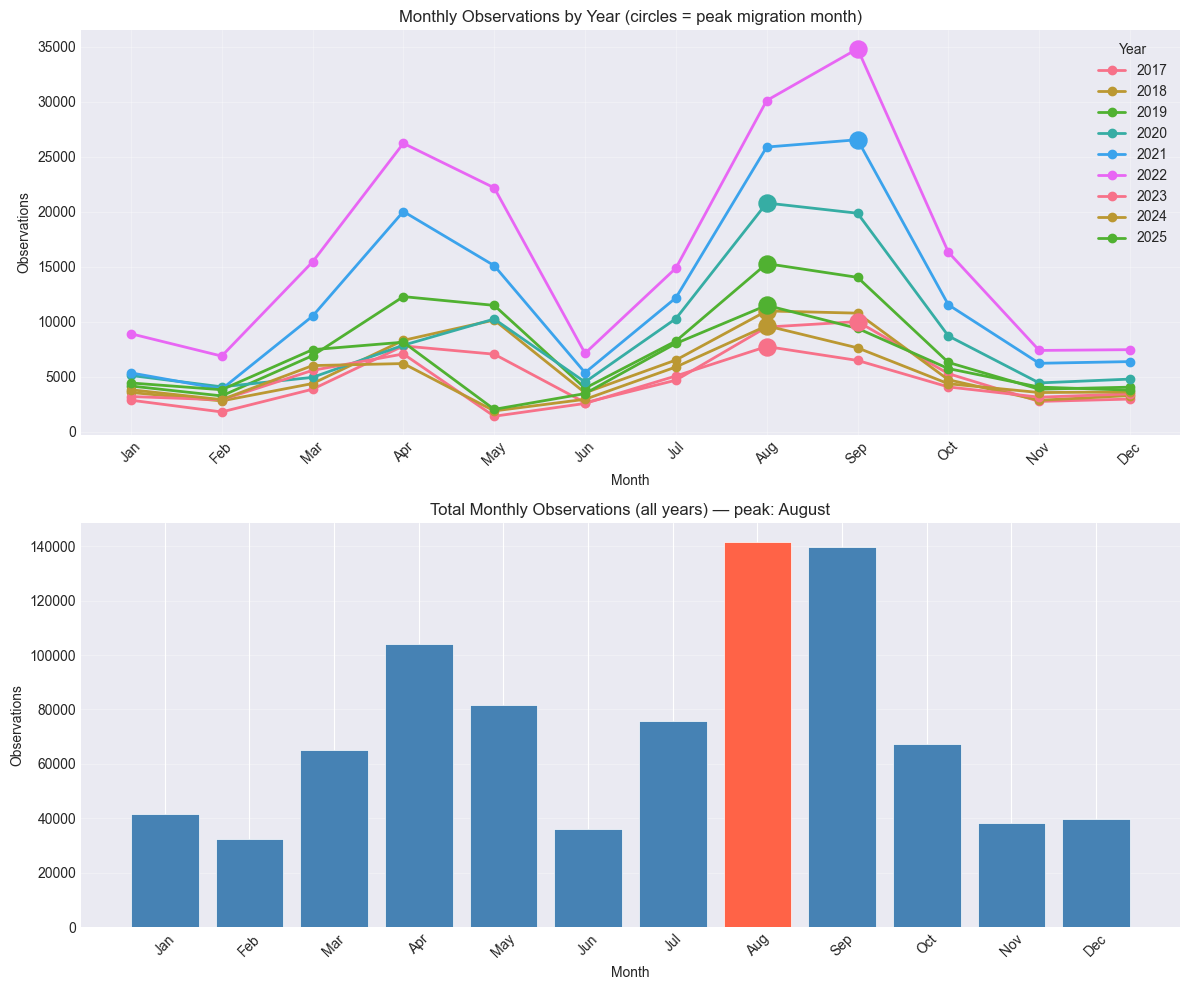

In [16]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').size().sort_index()
print("\nObservations by Year:")
for year, count in yearly_obs.items():
    if pd.notna(year):
        print(f"  {int(year)}: {count:,}")

# Month each year
month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
               7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}

peak_months_by_year = {}  # store peak month per year

yearly_obs = combined_df.groupby('year').size().sort_index()
for year in yearly_obs.index:
    print("\nObservations by month of", int(year))
    monthly_obs = combined_df[combined_df['year'] == year].groupby('month').size().sort_index()
    for month, count in monthly_obs.items():
        if pd.notna(month):
            print(f"  {month_names[int(month)]}: {count:,}")
    
    # Save peak month for this year
    peak_month = monthly_obs.idxmax()
    if pd.notna(peak_month):
        peak_months_by_year[int(year)] = {
            'month': int(peak_month),
            'month_name': month_names[int(peak_month)],
            'count': monthly_obs.max()
        }
        print(f"  → Peak migration month: {month_names[int(peak_month)]} ({monthly_obs.max():,} observations)")

# By month (all years combined)
monthly_obs = combined_df.groupby('month').size().sort_index()
print("\nObservations by Month (all years):")
for month, count in monthly_obs.items():
    if pd.notna(month):
        print(f"  {month_names[int(month)]}: {count:,}")

# Peak observation period
peak_month = monthly_obs.idxmax()
if pd.notna(peak_month):
    print(f"\nPeak observation month: {month_names[int(peak_month)]} ({monthly_obs.max():,} observations)")

# Print summary of peak months
print("\nPeak Migration Month by Year:")
for year, info in peak_months_by_year.items():
    print(f"  {year}: {info['month_name']} ({info['count']:,} observations)")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Monthly observations per year (lines)
ax1 = axes[0]
for year in yearly_obs.index:
    if pd.notna(year):
        monthly = combined_df[combined_df['year'] == year].groupby('month').size().reindex(range(1, 13), fill_value=0)
        ax1.plot(range(1, 13), monthly.values, marker='o', label=str(int(year)), linewidth=2)
        # Mark peak month
        if int(year) in peak_months_by_year:
            pm = peak_months_by_year[int(year)]['month']
            ax1.scatter(pm, monthly[pm], s=150, zorder=5)

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([month_names[m][:3] for m in range(1, 13)], rotation=45)
ax1.set_title('Monthly Observations by Year (circles = peak migration month)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Observations')
ax1.legend(title='Year')
ax1.grid(True, alpha=0.3)

# Plot 2: Combined monthly observations (bar)
ax2 = axes[1]
colors = ['tomato' if m == int(peak_month) else 'steelblue' for m in range(1, 13)]
monthly_all = combined_df.groupby('month').size().reindex(range(1, 13), fill_value=0)
bars = ax2.bar(range(1, 13), monthly_all.values, color=colors, edgecolor='white', linewidth=0.5)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels([month_names[m][:3] for m in range(1, 13)], rotation=45)
ax2.set_title(f'Total Monthly Observations (all years) — peak: {month_names[int(peak_month)]}')
ax2.set_xlabel('Month')
ax2.set_ylabel('Observations')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
#plt.savefig('temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
#print("\nPlot saved as 'temporal_analysis.png'")

In [17]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').agg(
    observations=('OBSERVER ID', 'count'),
    number_of_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).sort_index()

print("\nObservations by Year:")
for year, row in yearly_obs.iterrows():
    if pd.notna(year):
        print(f"  {int(year)}: {row['observations']:,} observations | {row['number_of_birds']:,} number of birds counted")
        #print(f"    Avg obs per observer: {(row['observations'] / row['unique_observers']):.2f}")




TEMPORAL ANALYSIS

Observations by Year:
  2017: 61,361.0 observations | 360,097.0 number of birds counted
  2018: 72,027.0 observations | 435,842.0 number of birds counted
  2019: 93,957.0 observations | 557,127.0 number of birds counted
  2020: 105,754.0 observations | 635,032.0 number of birds counted
  2021: 149,076.0 observations | 889,602.0 number of birds counted
  2022: 197,829.0 observations | 1,165,601.0 number of birds counted
  2023: 52,807.0 observations | 127,517.0 number of birds counted
  2024: 58,592.0 observations | 135,841.0 number of birds counted
  2025: 71,969.0 observations | 170,239.0 number of birds counted


In [18]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').agg(
    observations=('OBSERVER ID', 'count'),
    unique_observers=('OBSERVER ID', 'nunique'),
    number_of_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).sort_index()

print("\nObservations by Year:")
for year, row in yearly_obs.iterrows():
    if pd.notna(year):
        # print(f"  {int(year)}: {row['number_of_birds']:,} number of birds counted | {row['unique_observers']:,} unique observers")
        print(f"    Avg bird per observer: {(row['number_of_birds'] / row['unique_observers']):.2f}")
        # print(f"  {int(year)}: {row['observations']:,} observations | {row['unique_observers']:,} unique observers")
        print(f"    Avg obs per observer: {(row['observations'] / row['unique_observers']):.2f}")




TEMPORAL ANALYSIS

Observations by Year:
    Avg bird per observer: 85.21
    Avg obs per observer: 14.52
    Avg bird per observer: 82.59
    Avg obs per observer: 13.65
    Avg bird per observer: 86.73
    Avg obs per observer: 14.63
    Avg bird per observer: 102.54
    Avg obs per observer: 17.08
    Avg bird per observer: 106.41
    Avg obs per observer: 17.83
    Avg bird per observer: 103.06
    Avg obs per observer: 17.49
    Avg bird per observer: 16.17
    Avg obs per observer: 6.70
    Avg bird per observer: 14.66
    Avg obs per observer: 6.32
    Avg bird per observer: 14.78
    Avg obs per observer: 6.25


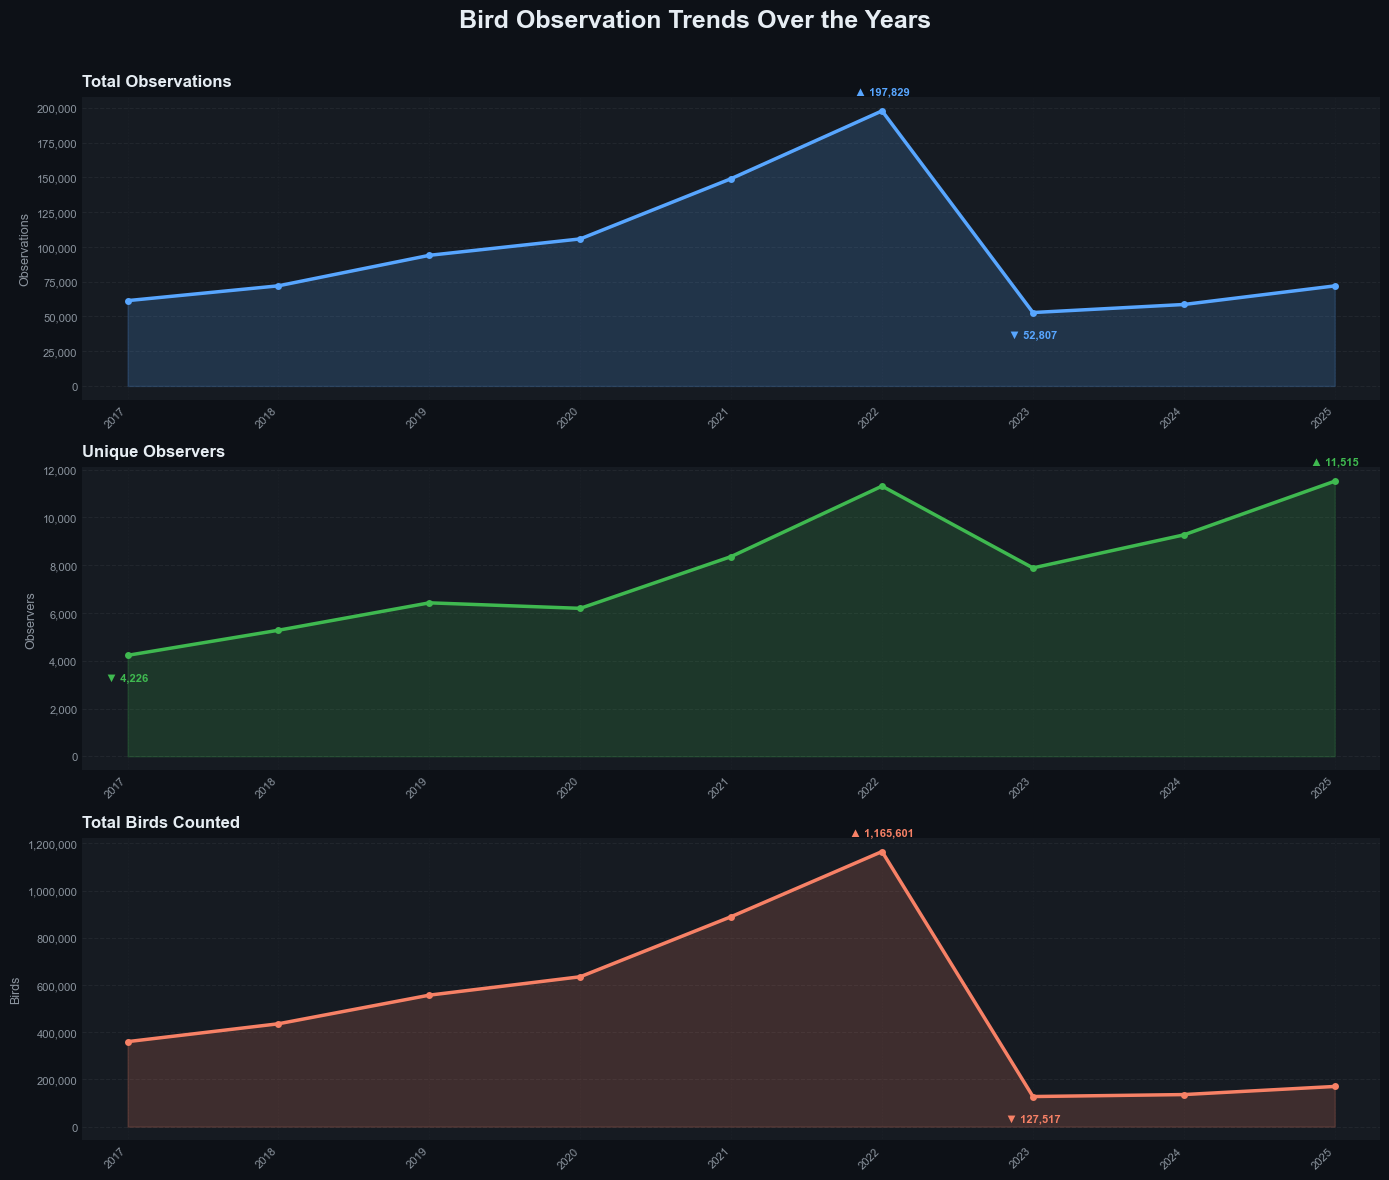

Plot saved to yearly_trends.png


In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 12), facecolor='#0d1117')
fig.suptitle('Bird Observation Trends Over the Years', 
             fontsize=18, fontweight='bold', color='#e6edf3', y=0.98)

years = yearly_obs.index.astype(int)

metrics = [
    ('observations',     '#58a6ff', 'Total Observations',     'Observations'),
    ('unique_observers', '#3fb950', 'Unique Observers',        'Observers'),
    ('number_of_birds',  '#f78166', 'Total Birds Counted',     'Birds'),
]

for ax, (col, color, title, ylabel) in zip(axes, metrics):
    values = yearly_obs[col].values

    ax.set_facecolor('#161b22')
    ax.fill_between(years, values, alpha=0.18, color=color)
    ax.plot(years, values, color=color, linewidth=2.5, marker='o',
            markersize=5, markerfacecolor=color, markeredgewidth=0)

    # Annotate min/max
    max_idx, min_idx = values.argmax(), values.argmin()
    for idx, label in [(max_idx, f'▲ {values[max_idx]:,.0f}'), 
                       (min_idx, f'▼ {values[min_idx]:,.0f}')]:
        ax.annotate(label, xy=(years[idx], values[idx]),
                    xytext=(0, 12 if idx == max_idx else -18),
                    textcoords='offset points', ha='center',
                    fontsize=8, color=color, fontweight='bold')

    ax.set_title(title, fontsize=12, color='#e6edf3', pad=8, loc='left', fontweight='bold')
    ax.set_ylabel(ylabel, color='#8b949e', fontsize=9)
    ax.tick_params(colors='#8b949e', labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_xlim(years[0] - 0.3, years[-1] + 0.3)
    ax.set_xticks(years)
    ax.set_xticklabels([str(y) for y in years], rotation=45, ha='right')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')
    ax.grid(axis='y', color='#21262d', linewidth=0.8, linestyle='--')
    ax.grid(axis='x', color='#21262d', linewidth=0.4, linestyle=':')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('yearly_trends.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Plot saved to yearly_trends.png")

### Year and locality type

In [26]:
yearly_obs = combined_df.groupby('year').size().sort_index()

print("\nObservations by Year:")
for year, count in yearly_obs.items():
    if pd.notna(year):
        print(f"  {int(year)}: {count:,}")
        locality_counts = (
            combined_df[combined_df['year'] == year]
            .groupby('LOCALITY TYPE')
            .size()
            .sort_values(ascending=False)
        )
        for locality, loc_count in locality_counts.items():
            print(f"    {locality}: {loc_count:,}")

        h = locality_counts.get('H', 0)
        p = locality_counts.get('P', 0)
        diff = h - p
        sign = "+" if diff > 0 else ""
        print(f"    H - P = {sign}{diff:,}")


Observations by Year:
  2017: 62,278
    H: 49,327
    P: 12,951
    H - P = +36,376
  2018: 73,152
    H: 58,124
    P: 15,028
    H - P = +43,096
  2019: 95,405
    H: 77,577
    P: 17,828
    H - P = +59,749
  2020: 107,613
    H: 88,026
    P: 19,587
    H - P = +68,439
  2021: 151,408
    H: 125,012
    P: 26,396
    H - P = +98,616
  2022: 200,670
    H: 167,722
    P: 32,948
    H - P = +134,774
  2023: 52,817
    H: 43,126
    P: 9,691
    H - P = +33,435
  2024: 58,605
    H: 47,844
    P: 10,761
    H - P = +37,083
  2025: 71,983
    H: 58,921
    P: 13,062
    H - P = +45,859


In [27]:
yearly_obs = combined_df.groupby('year').agg(
    observations=('OBSERVER ID', 'count'),
    unique_observers=('OBSERVER ID', 'nunique'),
    number_of_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).sort_index()

print("\nObservations by Year:")
for year, row in yearly_obs.iterrows():
    if pd.notna(year):
        print(f"  {int(year)}: {int(row['number_of_birds']):,} birds")
        locality_birds = (
            combined_df[combined_df['year'] == year]
            .groupby('LOCALITY TYPE')['howMany']
            .sum()
            .sort_values(ascending=False)
        )
        for locality, birds in locality_birds.items():
            print(f"    {locality}: {int(birds):,}")

        h = locality_birds.get('H', 0)
        p = locality_birds.get('P', 0)
        diff = h - p
        sign = "+" if diff > 0 else ""
        print(f"    H - P = {sign}{int(diff):,}")


Observations by Year:
  2017: 1,040,561 birds
    H: 841,731
    P: 198,830
    H - P = +642,901
  2018: 1,199,384 birds
    H: 962,206
    P: 237,178
    H - P = +725,028
  2019: 1,832,209 birds
    H: 1,439,767
    P: 392,442
    H - P = +1,047,325
  2020: 3,863,888 birds
    H: 2,857,262
    P: 1,006,626
    H - P = +1,850,636
  2021: 3,747,914 birds
    H: 3,293,586
    P: 454,328
    H - P = +2,839,258
  2022: 3,671,245 birds
    H: 3,338,585
    P: 332,660
    H - P = +3,005,925
  2023: 128,780 birds
    H: 108,689
    P: 20,091
    H - P = +88,598
  2024: 138,052 birds
    H: 116,040
    P: 22,012
    H - P = +94,028
  2025: 173,509 birds
    H: 147,112
    P: 26,397
    H - P = +120,715


### 8.3 Migration Pattern Analysis by Season

Analyzing bird sightings based on migration groups across different seasonal periods:
- **Spring Migration Period**: Mid-March to Mid-June
- **Summer Period**: July to Early August
- **Autumn Migration Period**: Late August to Early December  
- **Winter Period**: Late December to Early March

In [20]:
# Define seasonal periods
def get_season(date):
    """
    Classify observation date into seasonal periods.
    """
    if pd.isna(date):
        return 'Unknown'
    
    month = date.month
    day = date.day
    
    # Spring Migration: Mid-March (Mar 15) to Mid-June (Jun 15)
    if (month == 3 and day >= 15) or (month in [4, 5]) or (month == 6 and day <= 15):
        return 'Spring Migration (Mid-Mar to Mid-Jun)'
    
    # Summer: July and Early August (to Aug 20)
    elif month == 7 or (month == 8 and day <= 20):
        return 'Summer (Jul to Early Aug)'
    
    # Autumn Migration: Late August (Aug 21) to Early December (Dec 10)
    elif (month == 8 and day > 20) or (month in [9, 10, 11]) or (month == 12 and day <= 10):
        return 'Autumn Migration (Late Aug to Early Dec)'
    
    # Winter: Late December (Dec 11+) to Early March (Mar 14)
    else:  # (month == 12 and day > 10) or (month in [1, 2]) or (month == 3 and day < 15)
        return 'Winter (Late Dec to Early Mar)'

# Apply seasonal classification
combined_df['season'] = combined_df['obsDt'].apply(get_season)

print("Observations by season:")
season_counts = combined_df['season'].value_counts()
for season, count in season_counts.items():
    print(f"  {season}: {count:,} observations")

Observations by season:
  Autumn Migration (Late Aug to Early Dec): 316,228 observations
  Spring Migration (Mid-Mar to Mid-Jun): 246,637 observations
  Summer (Jul to Early Aug): 159,752 observations
  Winter (Late Dec to Early Mar): 140,755 observations
